<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch06_pyod_library.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: The PyOD Library

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

The **PyOD** (Python Outlier Detection) library provides the largest collection of outlier detectors for numeric tabular data in Python -- approximately $29$ traditional ML detectors and $8$ deep learning-based detectors, all behind a consistent API. Where scikit-learn provides four detectors, PyOD provides dozens, making it the most comprehensive toolkit for outlier detection experimentation.

This chapter covers a representative sample of PyOD's detectors, each illustrating a different approach to outlier detection. We also cover PyOD's tools for accelerating training (SUOD), thresholding scores (PyThresh), and explaining results (ECOD/COPOD explanations).

**Detectors covered:**
- **HBOS**: Histogram-based, univariate, extremely fast
- **ECOD**: Empirical CDF-based, parameter-free, univariate
- **COPOD**: Copula-based, parameter-free, with explanations
- **ABOD**: Angle-based, designed for high dimensions
- **CBLOF**: Clustering-based local outlier factor
- **PCA / KPCA**: Principal component analysis-based
- **SOD**: Subspace outlier detection
- **FeatureBagging**: Ensemble of subspace detectors
- **Cook's Distance**: Regression influence-based

## Environment Setup

In [9]:
!pip install pyod -q 2>/dev/null

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.decomposition import PCA as skPCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Verify PyOD
from pyod.models.knn import KNN
from pyod.models.hbos import HBOS
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.iforest import IForest
from pyod.models.pca import PCA as PyOD_PCA
from pyod.models.cblof import CBLOF

print("PyOD installed and ready.")
print("Detectors verified: KNN, HBOS, ECOD, COPOD, IForest, PCA, CBLOF")

PyOD installed and ready.
Detectors verified: KNN, HBOS, ECOD, COPOD, IForest, PCA, CBLOF


PyOD must be installed separately (`pip install pyod`). It wraps scikit-learn detectors (IF, LOF, OCSVM, KDE) and adds many more. All share a consistent API: `fit()`, `predict()`, `decision_scores_`, `decision_function()`, and `predict_proba()`.

## 6.1 The PyOD Common API

Every PyOD detector follows the same pattern:

```python
from pyod.models.xxx import XXX
clf = XXX()          # Create detector with default params
clf.fit(data)        # Fit on training data
scores = clf.decision_scores_   # Outlier scores for training data
labels = clf.labels_            # Binary labels for training data
```

For separate test data: `clf.predict(test_data)` returns labels, `clf.decision_function(test_data)` returns scores, and `clf.predict_proba(test_data)` returns normalized probabilities.

Higher scores always mean more outlierish. Let's demonstrate with PyOD's KNN detector.

Figure 6.1: PyOD KNN detector -- four views of results.
  Total points: 1010 (1000 inliers + 10 outliers)
  Binary predictions flagged: 81
  Score range: [0.0374, 11.1409]


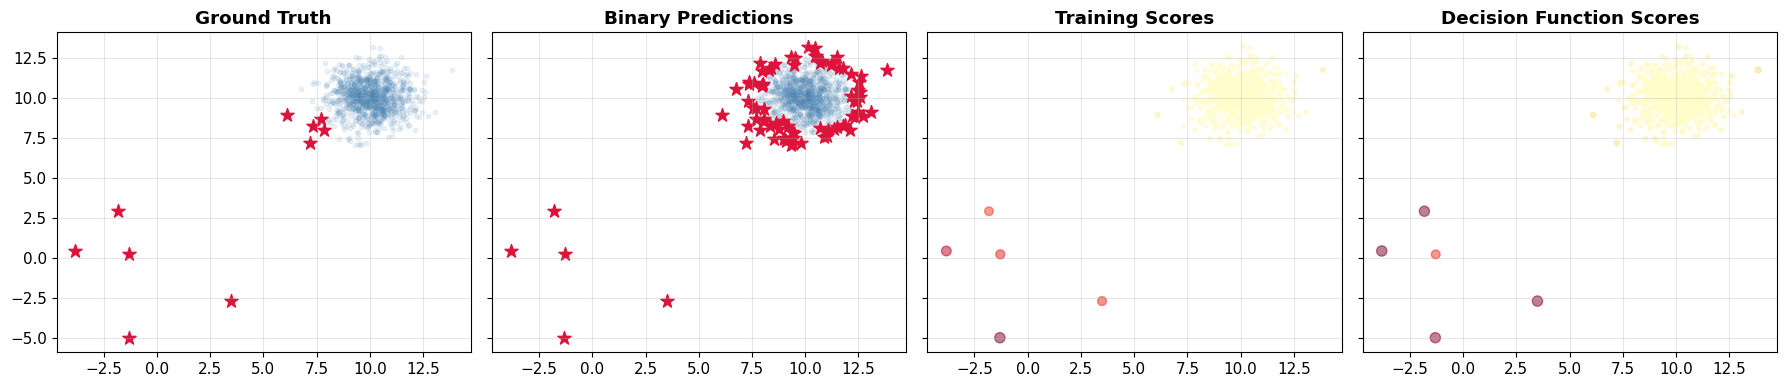

In [10]:
# Listing 6.3: Full PyOD API demonstration with KNN
from pyod.models.knn import KNN

np.random.seed(42)

# Create synthetic data: 1000 inliers + 5 edge outliers + 5 remote outliers
x_inlier = np.random.normal(loc=10, scale=1.0, size=1000)
y_inlier = np.random.normal(loc=10, scale=1.0, size=1000)
df1 = pd.DataFrame({'A': x_inlier, 'B': y_inlier})
df1['Ground_Truth'] = 0

x_edge = np.random.normal(loc=8, scale=1.0, size=5)
y_edge = np.random.normal(loc=8, scale=1.0, size=5)
df2 = pd.DataFrame({'A': x_edge, 'B': y_edge})
df2['Ground_Truth'] = 1

x_remote = np.random.normal(loc=1, scale=3.0, size=5)
y_remote = np.random.normal(loc=1, scale=3.0, size=5)
df3 = pd.DataFrame({'A': x_remote, 'B': y_remote})
df3['Ground_Truth'] = 1

df = pd.concat([df1, df2, df3], ignore_index=True)
df_scaled = pd.DataFrame(RobustScaler().fit_transform(df[['A','B']]), columns=['A','B'])

# Fit KNN
clf = KNN()
clf.fit(df_scaled)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

# Ground truth
ax = axes[0]
inlier_mask = df['Ground_Truth'] == 0
ax.scatter(df.loc[inlier_mask, 'A'], df.loc[inlier_mask, 'B'], alpha=0.1, s=10, c='steelblue')
ax.scatter(df.loc[~inlier_mask, 'A'], df.loc[~inlier_mask, 'B'], s=100, marker='*', c='crimson')
ax.set_title('Ground Truth', fontweight='bold')

# Binary predictions
pred_labels = clf.predict(df_scaled)
ax = axes[1]
pred_inlier = pred_labels == 0
ax.scatter(df.loc[pred_inlier, 'A'], df.loc[pred_inlier, 'B'], alpha=0.1, s=10, c='steelblue')
ax.scatter(df.loc[~pred_inlier, 'A'], df.loc[~pred_inlier, 'B'], s=100, marker='*', c='crimson')
ax.set_title('Binary Predictions', fontweight='bold')

# Training scores
scores_train = clf.decision_scores_
ax = axes[2]
sc = ax.scatter(df['A'], df['B'], c=scores_train, s=5 + 50*(scores_train/scores_train.max()),
                cmap='YlOrRd', alpha=0.5)
ax.set_title('Training Scores', fontweight='bold')

# Decision function scores
scores_test = clf.decision_function(df_scaled)
ax = axes[3]
sc = ax.scatter(df['A'], df['B'], c=scores_test, s=5 + 50*(scores_test/scores_test.max()),
                cmap='YlOrRd', alpha=0.5)
ax.set_title('Decision Function Scores', fontweight='bold')

plt.tight_layout()

print(f"Figure 6.1: PyOD KNN detector -- four views of results.")
print(f"  Total points: {len(df)} (1000 inliers + 10 outliers)")
print(f"  Binary predictions flagged: {(~pred_inlier).sum()}")
print(f"  Score range: [{scores_train.min():.4f}, {scores_train.max():.4f}]")

This recreates Figure 6.1 from the book, showing four views of the same KNN detection:

**Ground Truth** (left): The $10$ planted outliers -- $5$ near the cluster edge, $5$ far away.

**Binary Predictions**: PyOD's `predict()` applies a threshold based on the `contamination` parameter (default $0.1$). It flags more than $10$ points because the default assumes $10\%$ contamination.

**Training Scores**: `decision_scores_` provides continuous scores computed during `fit()`. The color and size encode outlierness -- the remote outliers clearly score highest.

**Decision Function Scores**: `decision_function()` scores the same data as a "test" set, producing nearly identical results (small differences may arise from BallTree approximations).

The consistent API means switching from KNN to any other detector requires changing only the import and constructor.

## 6.2 Histogram-Based Outlier Score (HBOS)

**HBOS** is designed above all for **speed**. It treats each feature completely independently, creating a histogram for each and scoring values based on the inverse bin density. The final score is the sum across features.

HBOS detects only **univariate outliers** (no unusual combinations), but this is often sufficient -- univariate outliers are frequently the most extreme and actionable. And HBOS is among the **fastest detectors available**, making it ideal for real-time environments or datasets with hundreds of features.

HBOS on 100-feature data (3000 samples):
  Score range: [130.86, 181.72]
  Planted outlier recall (top 20): 55.0%


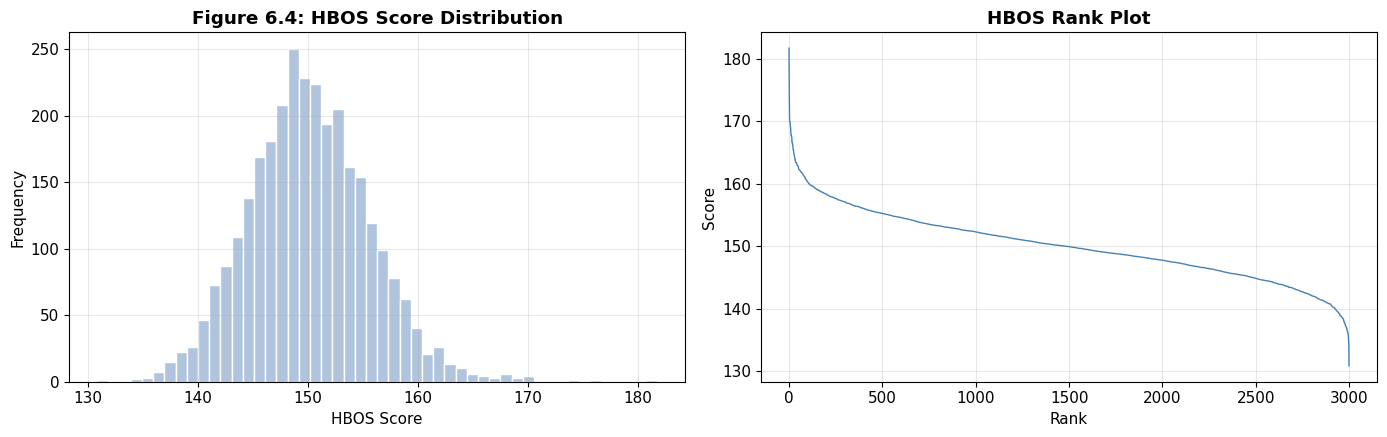

In [11]:
# HBOS on synthetic high-dimensional data (simulating speech dataset)
from pyod.models.hbos import HBOS

np.random.seed(42)
n_samples = 3000
n_features = 100

# Simulate speech-like data: mostly normal with some features having outlier values
X_speech = np.random.normal(0, 1, (n_samples, n_features))
# Inject outliers: last 20 rows have extreme values in random features
for i in range(n_samples - 20, n_samples):
    n_extreme = np.random.randint(3, 15)
    extreme_feats = np.random.choice(n_features, n_extreme, replace=False)
    X_speech[i, extreme_feats] = np.random.choice([-1, 1], n_extreme) * np.random.uniform(3, 6, n_extreme)

df_speech = pd.DataFrame(X_speech, columns=[f'V{i+1}' for i in range(n_features)])

det = HBOS()
det.fit(df_speech)
hbos_scores = det.decision_scores_

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.hist(hbos_scores, bins=50, color='lightsteelblue', edgecolor='white')
ax.set_xlabel('HBOS Score')
ax.set_ylabel('Frequency')
ax.set_title('Figure 6.4: HBOS Score Distribution', fontweight='bold')

# Rank plot
ax = axes[1]
ax.plot(range(len(hbos_scores)), sorted(hbos_scores, reverse=True), 'steelblue', linewidth=1)
ax.set_xlabel('Rank')
ax.set_ylabel('Score')
ax.set_title('HBOS Rank Plot', fontweight='bold')

plt.tight_layout()

# Check: are the planted outliers scored highest?
top_20 = np.argsort(hbos_scores)[-20:]
planted = set(range(n_samples-20, n_samples))
recall = len(set(top_20) & planted) / len(planted)
print(f"HBOS on {n_features}-feature data ({n_samples} samples):")
print(f"  Score range: [{hbos_scores.min():.2f}, {hbos_scores.max():.2f}]")
print(f"  Planted outlier recall (top 20): {recall:.1%}")

HBOS produces a clean score distribution with a right tail of increasingly outlierish points. The rank plot helps identify where to set a threshold.

**How HBOS works:** For each feature, it creates a histogram with $n$ equal-width bins (default $10$). Each bin gets a density score inversely proportional to its count. For a given row, HBOS looks up which bin each value falls into, gets the bin's score, and **sums across all features**. Rows with many rare values (in low-count bins) receive high total scores.

**Key properties:**
- **Very fast**: $O(n \cdot d)$ where $d$ is the number of features -- linear in both
- **Handles many features**: no distance calculations, so no curse of dimensionality
- **Finds internal outliers**: any low-count bin is flagged, not just extremes
- **Sensitive to n_bins**: the `n_bins` parameter (or `"auto"`) affects results significantly
- **No multivariate detection**: treats features independently

## 6.3 Empirical Cumulative Distribution Function (ECOD)

**ECOD** is one of PyOD's recommended starting detectors (along with Isolation Forest). Its biggest advantage: **no parameters at all**. There is nothing to tune, which is extremely appealing given the difficulty of tuning without labeled data.

Like HBOS, ECOD treats features independently. But instead of histograms (which require choosing bin counts), ECOD uses the **empirical cumulative distribution function (ECDF)** -- a bin-free, continuous representation of each feature's distribution.

ECOD identifies extreme values in the **tails** of each feature's ECDF. For each value, it computes the tail probability (how likely a value at least this extreme is), then aggregates across features. Unlike HBOS, ECOD cannot detect internal outliers -- only extreme values.

Figure 6.7: Histograms with different bin counts vs ECDF.
The ECDF is bin-free and provides a consistent representation regardless of parameters.


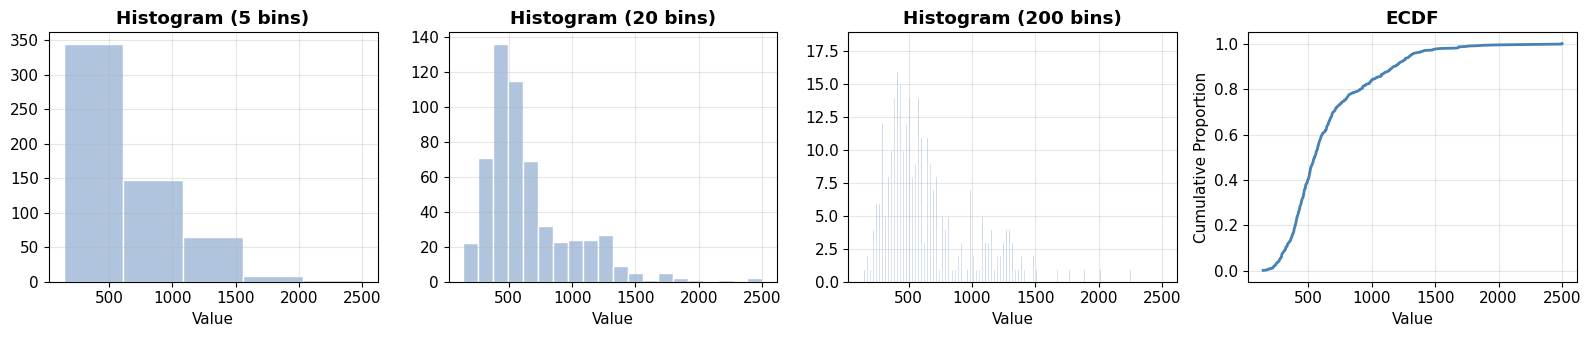

In [12]:
# ECDF visualization (Figure 6.7)
from sklearn.datasets import load_breast_cancer

data_bc = load_breast_cancer()['data']
col = 3  # mean area

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, nbins, title in zip(axes[:3], [5, 20, 200], ['5 bins', '20 bins', '200 bins']):
    ax.hist(data_bc[:, col], bins=nbins, color='lightsteelblue', edgecolor='white')
    ax.set_title(f'Histogram ({title})', fontweight='bold')
    ax.set_xlabel('Value')

ax = axes[3]
sorted_vals = np.sort(data_bc[:, col])
ecdf_y = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
ax.plot(sorted_vals, ecdf_y, 'steelblue', linewidth=2)
ax.set_title('ECDF', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Cumulative Proportion')

plt.tight_layout()
print("Figure 6.7: Histograms with different bin counts vs ECDF.")
print("The ECDF is bin-free and provides a consistent representation regardless of parameters.")

This recreates Figure 6.7. The three histograms look quite different depending on the bin count -- $5$ bins give a coarse view, $200$ bins show noise. The **ECDF** (right) is the same regardless -- it maps each value to the proportion of data at or below that value. Steep sections correspond to dense regions; flat sections to sparse tails.

ECOD uses ECDF to identify tail probabilities: for each value in each feature, it computes $P(X \leq x)$ from the left tail and $P(X \geq x)$ from the right tail. Values deep in a tail get small probabilities (high outlier scores). The per-feature scores are aggregated by multiplication (in log-space: addition of negative log-probabilities).

ECOD also corrects for **skewness**: for highly skewed features, only one tail may contain meaningful outliers, and ECOD adjusts accordingly.

ECOD results:
  Top outlier: row 2992, score = 263.17
  Features above 0.9 cutoff: 9
  Features above 0.99 cutoff: 0
  Planted outlier recall (top 20): 70.0%


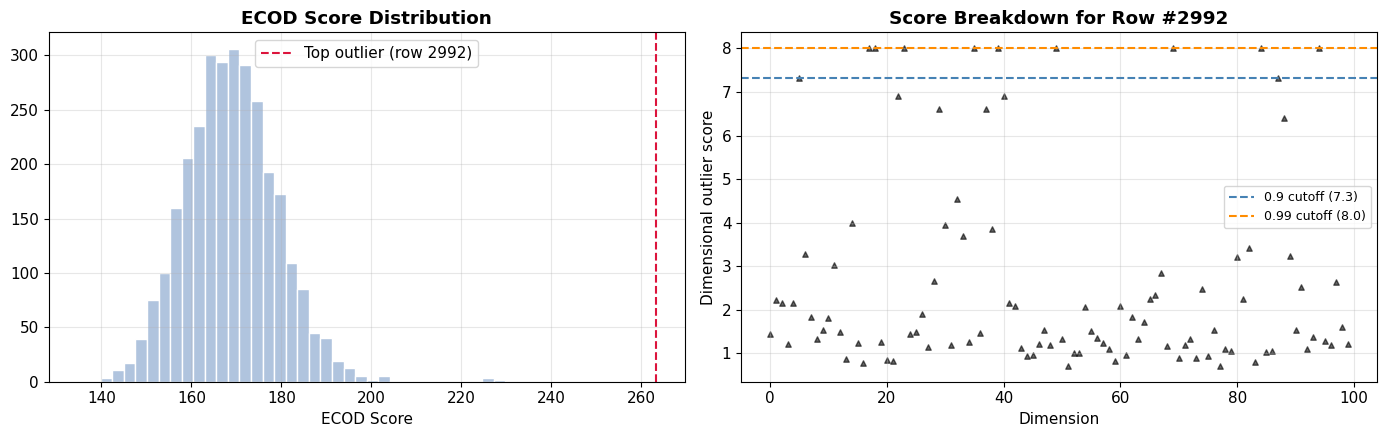

In [13]:
# ECOD on synthetic data with explain_outlier
from pyod.models.ecod import ECOD

np.random.seed(42)
det_ecod = ECOD()
det_ecod.fit(df_speech)
ecod_scores = det_ecod.decision_scores_

# Find the highest-scored row
top_idx = np.argmax(ecod_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.hist(ecod_scores, bins=50, color='lightsteelblue', edgecolor='white')
ax.axvline(ecod_scores[top_idx], color='crimson', linestyle='--', label=f'Top outlier (row {top_idx})')
ax.set_xlabel('ECOD Score')
ax.set_title('ECOD Score Distribution', fontweight='bold')
ax.legend()

# Manual explanation: show per-feature scores for top outlier
# ECOD stores per-feature scores in O attribute
ax = axes[1]
if hasattr(det_ecod, 'O'):
    per_feat = det_ecod.O[top_idx]
    ax.scatter(range(len(per_feat)), per_feat, c='black', s=15, marker='^', alpha=0.6)
    p90 = np.percentile(per_feat, 90)
    p99 = np.percentile(per_feat, 99)
    ax.axhline(p90, color='steelblue', linestyle='--', label=f'0.9 cutoff ({p90:.1f})')
    ax.axhline(p99, color='darkorange', linestyle='--', label=f'0.99 cutoff ({p99:.1f})')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Dimensional outlier score')
    ax.set_title(f'Score Breakdown for Row #{top_idx}', fontweight='bold')
    ax.legend(fontsize=9)
    n_above_90 = (per_feat > p90).sum()
    n_above_99 = (per_feat > p99).sum()
else:
    ax.text(0.5, 0.5, 'O attribute not available', ha='center', va='center', transform=ax.transAxes)
    n_above_90, n_above_99 = 0, 0

plt.tight_layout()

top20_ecod = np.argsort(ecod_scores)[-20:]
planted = set(range(n_samples-20, n_samples))
recall_ecod = len(set(top20_ecod) & planted) / len(planted)
print(f"ECOD results:")
print(f"  Top outlier: row {top_idx}, score = {ecod_scores[top_idx]:.2f}")
print(f"  Features above 0.9 cutoff: {n_above_90}")
print(f"  Features above 0.99 cutoff: {n_above_99}")
print(f"  Planted outlier recall (top 20): {recall_ecod:.1%}")

The right panel recreates the book's Figure 6.8 -- an **explanation plot** showing per-feature outlier scores for the highest-scored row. Each triangle represents one feature's contribution. Features above the $0.9$ cutoff band (blue dashed) are moderately extreme; those above the $0.99$ band (orange dashed) are highly extreme.

This per-feature explanation is available only for ECOD and COPOD among PyOD detectors. It is accessed via the `explain_outlier()` method or manually from the `O` attribute. This interpretability is a major practical advantage -- when an analyst investigates a flagged record, knowing *which features* drove the score dramatically reduces investigation time.

## 6.4 Copula-Based Outlier Detection (COPOD)

**COPOD** is similar to ECOD but more sophisticated. It uses **empirical copulas** to model the joint distribution of features, providing slightly more nuanced scores. Like ECOD, it is **parameter-free**, very fast, and provides per-feature explanations.

COPOD works in three steps:
1. Compute ECDFs for each feature
2. Construct an **empirical copula** from these ECDFs
3. Estimate tail probabilities using the copula

The copula-based approach accounts for the joint behavior of features in a way that simple per-feature ECDF analysis does not, though both are fundamentally univariate in their detection of extreme values.

Figure 6.10: COPOD explanation for row 999 (1-indexed: 1000).
  Feature A (extreme): score = 6.91
  Feature B (normal):  score = 1.60
  COPOD correctly identifies Feature A as the anomalous dimension.


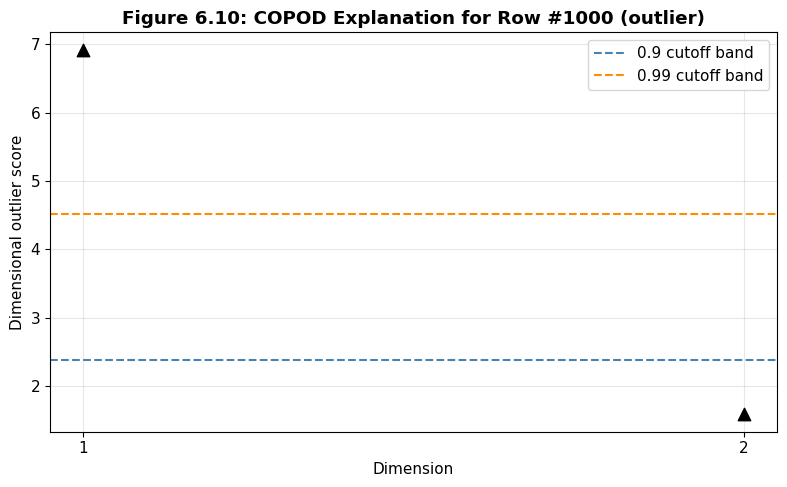

In [14]:
# COPOD with synthetic data + explain_outlier (Figure 6.10)
from pyod.models.copod import COPOD

# Simple 2D example for clear explanation
np.random.seed(42)
a_data = np.random.normal(loc=10, scale=1.0, size=1000)
b_data = np.random.normal(loc=10, scale=1.0, size=1000)
df_simple = pd.DataFrame({"A": a_data, "B": b_data})
df_simple.loc[999, 'A'] = 15  # inject extreme value in first feature only

clf_copod = COPOD()
clf_copod.fit(df_simple)

# Explanation for the known outlier
fig, ax = plt.subplots(figsize=(8, 5))

if hasattr(clf_copod, 'O'):
    per_feat = clf_copod.O[999]
    ax.scatter(range(1, len(per_feat)+1), per_feat, c='black', s=80, marker='^', zorder=5)
    p90 = np.percentile(clf_copod.O, 90)
    p99 = np.percentile(clf_copod.O, 99)
    ax.axhline(p90, color='steelblue', linestyle='--', linewidth=1.5, label=f'0.9 cutoff band')
    ax.axhline(p99, color='darkorange', linestyle='--', linewidth=1.5, label=f'0.99 cutoff band')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Dimensional outlier score')
    ax.set_title(f'Figure 6.10: COPOD Explanation for Row #1000 (outlier)', fontweight='bold')
    ax.set_xticks([1, 2])
    ax.legend()

plt.tight_layout()
print(f"Figure 6.10: COPOD explanation for row 999 (1-indexed: 1000).")
print(f"  Feature A (extreme): score = {per_feat[0]:.2f}")
print(f"  Feature B (normal):  score = {per_feat[1]:.2f}")
print(f"  COPOD correctly identifies Feature A as the anomalous dimension.")

This recreates Figure 6.10 from the book. COPOD correctly identifies that **Feature A** (Dimension 1) has an extreme value well above the $0.99$ cutoff, while **Feature B** (Dimension 2) has a normal value below both cutoff bands. This per-feature decomposition is invaluable for understanding *why* a record was flagged.

**ECOD vs. COPOD:** Both are parameter-free, fast, and provide explanations. ECOD is simpler (pure ECDF); COPOD is more sophisticated (copula-based). In practice, they often agree on the most extreme outliers but may differ on borderline cases. Both are excellent starting points for any outlier detection project.

## 6.5 Angle-Based Outlier Detection (ABOD)

**ABOD** was specifically designed for **high-dimensional data**. Instead of distances (which suffer from concentration in high dimensions), ABOD uses **angles** between points. The insight: for an inlier surrounded by other points, the angles to pairs of neighbors vary widely. For an outlier on the periphery, the angles are all similar (everything is "in the same direction").

ABOD scores each point by the **variance** of the angles formed with all pairs of other points. Low variance = outlier. High variance = inlier. The full algorithm is $O(n^3)$, but PyOD uses a sample-based approximation (fastABOD) by default.

ABOD results:
  Planted outlier scores: [-0.001 -0.008 -0.012 -0.001]
  All 4 planted outliers in top 8: True


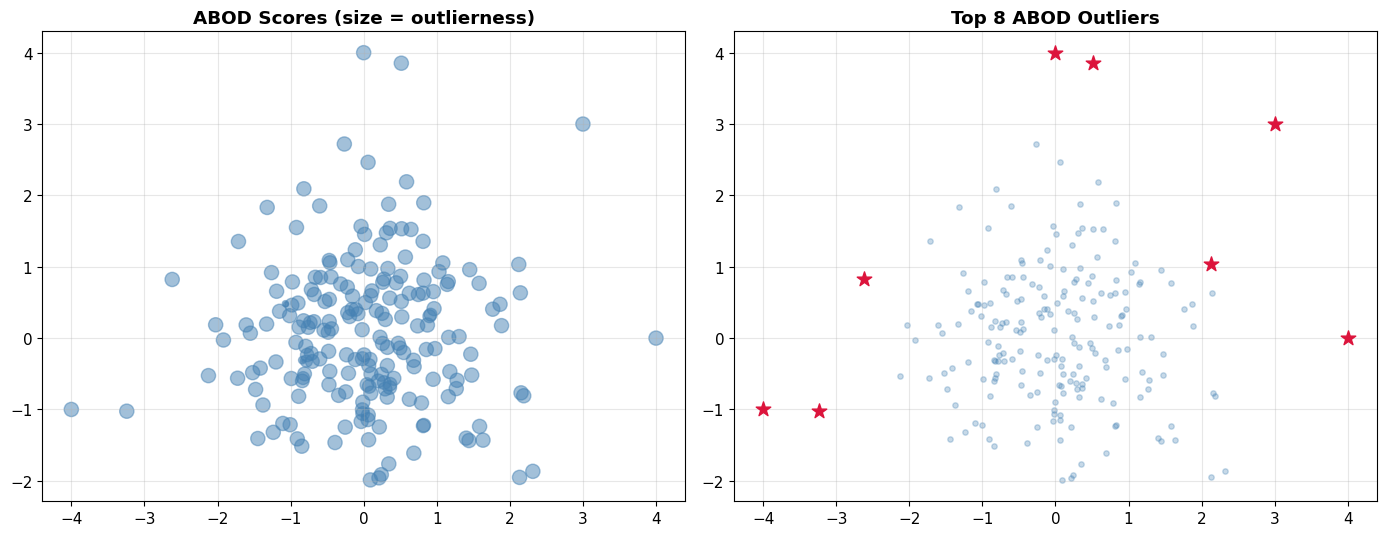

In [15]:
# ABOD demonstration
from pyod.models.abod import ABOD

np.random.seed(42)
# 2D data for visualization
X_abod = np.random.normal(0, 1, (200, 2))
# Add outliers
outliers_abod = np.array([[4, 0], [0, 4], [-4, -1], [3, 3]])
X_all = np.vstack([X_abod, outliers_abod])

det_abod = ABOD(n_neighbors=20)
det_abod.fit(X_all)
abod_scores = det_abod.decision_scores_

# Clean infinite values
abod_scores = np.where(np.isinf(abod_scores), np.nanmax(abod_scores[~np.isinf(abod_scores)]), abod_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Sized by score
ax = axes[0]
sizes = 5 + 100 * (abod_scores - abod_scores.min()) / (abod_scores.max() - abod_scores.min() + 1e-10)
ax.scatter(X_all[:, 0], X_all[:, 1], s=sizes, alpha=0.5, c='steelblue')
ax.set_title('ABOD Scores (size = outlierness)', fontweight='bold')

# Top outliers
n_top = 8
threshold = np.sort(abod_scores)[-n_top]
flagged = abod_scores >= threshold
ax = axes[1]
ax.scatter(X_all[~flagged, 0], X_all[~flagged, 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_all[flagged, 0], X_all[flagged, 1], c='crimson', s=120, marker='*', zorder=5)
ax.set_title(f'Top {n_top} ABOD Outliers', fontweight='bold')

plt.tight_layout()

# Check planted outliers
planted_scores = abod_scores[-4:]
print(f"ABOD results:")
print(f"  Planted outlier scores: {np.round(planted_scores, 3)}")
print(f"  All 4 planted outliers in top {n_top}: {all(s >= threshold for s in planted_scores)}")

ABOD correctly identifies the planted outliers at the periphery. The angle-based approach provides an alternative perspective to distance-based methods and can complement them in an ensemble.

**Figure 6.11 intuition:** For an inlier at the center of a cluster, picking any two other points creates angles that range from very narrow to very wide -- high variance. For an outlier far from the cluster, all other points are roughly in the same direction, so angles are all similar -- low variance. ABOD converts this low variance to a high outlier score.

**Practical notes:** ABOD can produce infinite scores (cleaned with max substitution), and some researchers have found it does not always scale better than LOF in practice. It is most useful as part of an ensemble providing a complementary perspective.

## 6.6 Clustering-Based Local Outlier Factor (CBLOF)

**CBLOF** combines clustering with outlier scoring. It first clusters the data (using k-means by default), classifies clusters as **large** or **small**, then scores each point based on its distance to the nearest **large** cluster center. Points in small clusters or far from any large cluster center receive high scores.

The insight: points in small clusters might reasonably belong to a nearby large cluster (just placed in a small cluster by the quirks of the clustering algorithm). Evaluating them relative to the nearest large cluster provides a more stable assessment than using their own tiny cluster.

CBLOF results (n_clusters=10):
  Score range: [0.06, 8.90]
  Top outliers include noise points and small-cluster members.


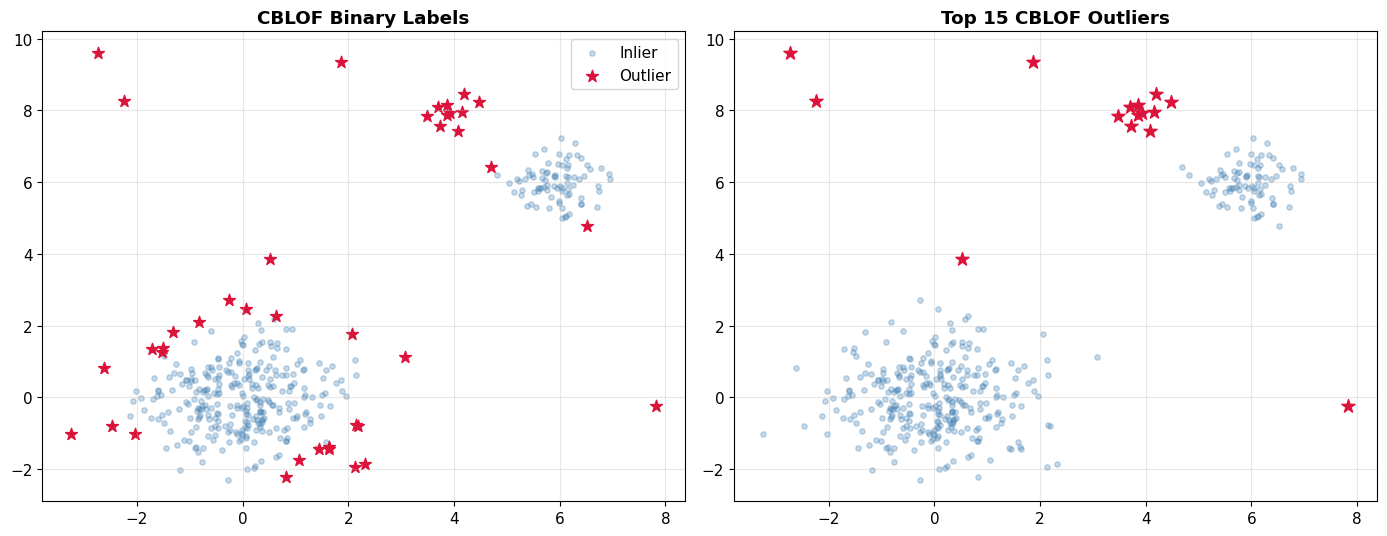

In [17]:
# CBLOF demonstration (Figure 6.12 concept)
from pyod.models.cblof import CBLOF

np.random.seed(42)
# Three clusters: one large, one medium, one small
c1, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=1.0, random_state=42)
c2, _ = make_blobs(n_samples=80, centers=[[6, 6]], cluster_std=0.5, random_state=42)
c3, _ = make_blobs(n_samples=10, centers=[[4, 8]], cluster_std=0.3, random_state=42)
noise = np.random.uniform(-3, 10, (8, 2))
X_cblof = np.vstack([c1, c2, c3, noise])

det_cblof = CBLOF(n_clusters=10, alpha=0.8, beta=3)
det_cblof.fit(X_cblof)
cblof_scores = det_cblof.decision_scores_

n_top = 15
threshold = np.sort(cblof_scores)[-n_top]
flagged = cblof_scores >= threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Cluster labels
ax = axes[0]
labels_cblof = det_cblof.labels_
ax.scatter(X_cblof[labels_cblof==0, 0], X_cblof[labels_cblof==0, 1], alpha=0.3, s=15, c='steelblue', label='Inlier')
ax.scatter(X_cblof[labels_cblof==1, 0], X_cblof[labels_cblof==1, 1], c='crimson', s=80, marker='*', label='Outlier')
ax.set_title('CBLOF Binary Labels', fontweight='bold')
ax.legend()

# Scores
ax = axes[1]
ax.scatter(X_cblof[~flagged, 0], X_cblof[~flagged, 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_cblof[flagged, 0], X_cblof[flagged, 1], c='crimson', s=100, marker='*', zorder=5)
ax.set_title(f'Top {n_top} CBLOF Outliers', fontweight='bold')

plt.tight_layout()
print(f"CBLOF results (n_clusters=10):")
print(f"  Score range: [{cblof_scores.min():.2f}, {cblof_scores.max():.2f}]")
print(f"  Top outliers include noise points and small-cluster members.")

CBLOF correctly identifies noise points (far from all clusters) and members of the small cluster C3, which are evaluated relative to the nearest large cluster C2. Points deep inside C1 and C2 receive low scores.

**CBLOF vs. DBSCAN for outlier detection:** DBSCAN labels points as "in a cluster" or "noise" (binary). CBLOF provides **continuous scores** based on distance to large cluster centers and considers cluster sizes, giving a more nuanced ranking. CBLOF is likely, along with DBSCAN and GMM, among the most commonly used clustering-based approaches for outlier detection.

## 6.7 Principal Component Analysis (PCA) for Outlier Detection

PCA transforms data into uncorrelated **components** ordered by variance. The first component captures the most variance; later components capture progressively less. This transformation is powerful for outlier detection because:

1. **Extreme values along dominant patterns** appear as outliers in the first components
2. **Deviations from dominant patterns** appear as outliers in the later components
3. **Reconstruction error** (using only the first $k$ components) directly measures how well a point fits the main patterns

PyOD provides a PCA detector that uses **reconstruction error** as the outlier score.

Figure 6.13: PCA transformation revealing two types of outliers.
  Explained variance: PC1=0.993, PC2=0.007
  Point A: extreme along the dominant pattern -> outlier in PC1
  Point B: deviates from the pattern -> outlier in PC2


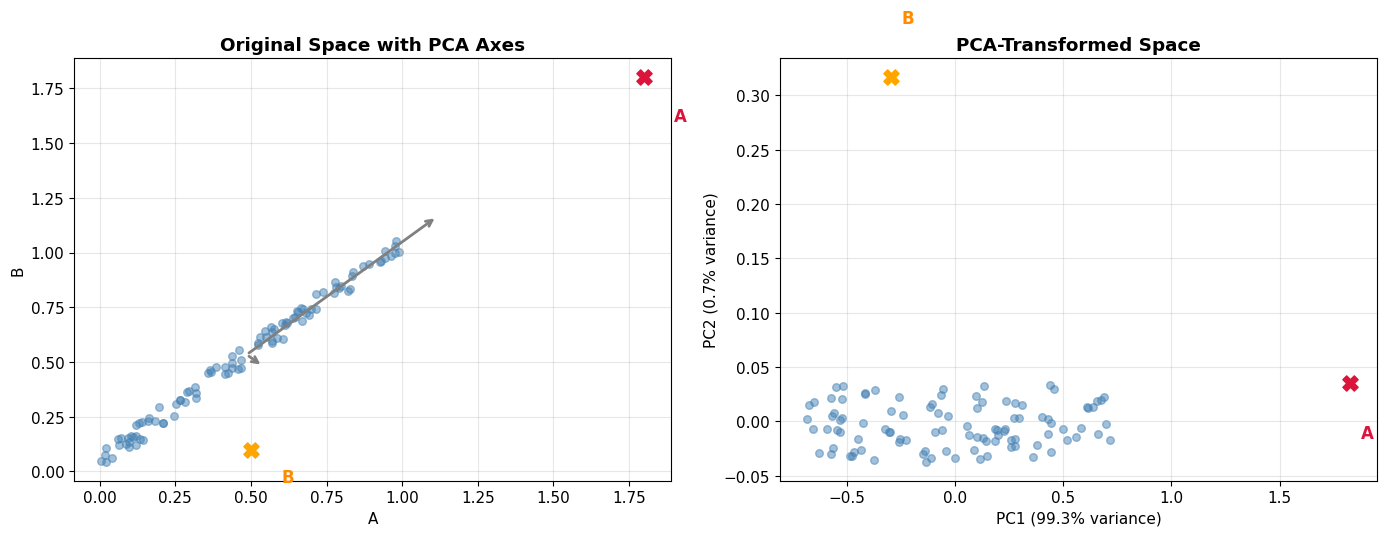

In [18]:
# Listing 6.9: PCA transformation for outlier detection
from sklearn.decomposition import PCA as skPCA

np.random.seed(0)
x_data = np.random.random(100)
y_data = np.random.random(100) / 10.0
data_pca = pd.DataFrame({'A': x_data, 'B': x_data + y_data})
# Add two outliers
data_pca = pd.concat([data_pca, pd.DataFrame([[1.8, 1.8], [0.5, 0.1]], columns=['A', 'B'])], ignore_index=True)

pca = skPCA(n_components=2)
pca.fit(data_pca)
transformed = pd.DataFrame(pca.transform(data_pca), columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Original space
ax = axes[0]
ax.scatter(data_pca.iloc[:-2]['A'], data_pca.iloc[:-2]['B'], alpha=0.5, s=30, c='steelblue')
ax.scatter(data_pca.iloc[-2]['A'], data_pca.iloc[-2]['B'], c='crimson', s=120, marker='X', zorder=5)
ax.scatter(data_pca.iloc[-1]['A'], data_pca.iloc[-1]['B'], c='orange', s=120, marker='X', zorder=5)
ax.annotate('A', xy=(1.8, 1.8), xytext=(1.9, 1.6), fontsize=12, fontweight='bold', color='crimson')
ax.annotate('B', xy=(0.5, 0.1), xytext=(0.6, -0.05), fontsize=12, fontweight='bold', color='darkorange')
# Show PCA axes
origin = data_pca.mean().values
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    ax.annotate('', xy=origin + comp * np.sqrt(var) * 2, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.set_title('Original Space with PCA Axes', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')

# PCA space
ax = axes[1]
ax.scatter(transformed.iloc[:-2]['PC1'], transformed.iloc[:-2]['PC2'], alpha=0.5, s=30, c='steelblue')
ax.scatter(transformed.iloc[-2]['PC1'], transformed.iloc[-2]['PC2'], c='crimson', s=120, marker='X', zorder=5)
ax.scatter(transformed.iloc[-1]['PC1'], transformed.iloc[-1]['PC2'], c='orange', s=120, marker='X', zorder=5)
ax.annotate('A', xy=(transformed.iloc[-2]['PC1'], transformed.iloc[-2]['PC2']),
            xytext=(transformed.iloc[-2]['PC1']+0.05, transformed.iloc[-2]['PC2']-0.05),
            fontsize=12, fontweight='bold', color='crimson')
ax.annotate('B', xy=(transformed.iloc[-1]['PC1'], transformed.iloc[-1]['PC2']),
            xytext=(transformed.iloc[-1]['PC1']+0.05, transformed.iloc[-1]['PC2']+0.05),
            fontsize=12, fontweight='bold', color='darkorange')
ax.set_title('PCA-Transformed Space', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

plt.tight_layout()

print(f"Figure 6.13: PCA transformation revealing two types of outliers.")
print(f"  Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"  Point A: extreme along the dominant pattern -> outlier in PC1")
print(f"  Point B: deviates from the pattern -> outlier in PC2")

This recreates Figure 6.13. In the original space (left), both outliers are visible but for different reasons. After PCA transformation (right):

**Point A** (extreme along the pattern): It has the highest value on **PC1** (the dominant component). It follows the general trend but is extreme -- an outlier in the major component.

**Point B** (deviates from the pattern): It has typical values in each dimension individually, but its combination violates the strong correlation. It appears as an extreme value on **PC2** (the minor component) -- an outlier in the residual variance.

This dual perspective is PCA's unique strength for outlier detection: **major components capture extreme-but-patterned outliers**, while **minor components capture pattern-violating outliers**. PyOD's PCA detector uses reconstruction error from the first $k$ components, primarily catching the second type.

In [19]:
# PyOD PCA detector
from pyod.models.pca import PCA as PyOD_PCA

# Use the synthetic speech-like data
det_pca = PyOD_PCA()
det_pca.fit(df_speech)
pca_scores = det_pca.decision_scores_

top20_pca = np.argsort(pca_scores)[-20:]
planted = set(range(n_samples-20, n_samples))
recall_pca = len(set(top20_pca) & planted) / len(planted)

print(f"PyOD PCA detector on {n_features}-feature data:")
print(f"  Score range: [{pca_scores.min():.2f}, {pca_scores.max():.2f}]")
print(f"  Planted outlier recall (top 20): {recall_pca:.1%}")

PyOD PCA detector on 100-feature data:
  Score range: [76227.42, 214381.07]
  Planted outlier recall (top 20): 95.0%


PyOD's PCA detector captures outliers that deviate from the dominant linear patterns in the data. It complements HBOS and ECOD, which focus on univariate extremes: PCA can catch points with individually normal values but unusual *combinations* -- the multivariate outliers that univariate methods miss.

## 6.8 Subspace Outlier Detection (SOD) and FeatureBagging

When datasets have many features, most outliers are unusual in only a **small subset** of features. Examining all features at once dilutes the signal (curse of dimensionality). **Subspace methods** address this by examining small subsets of features.

**SOD** identifies, for each point, the subspace (subset of features) where it is most unusual, using **shared nearest neighbors** to find relevant neighborhoods.

**FeatureBagging** creates an ensemble of detectors, each using a random subset of features and rows. The final score is the maximum (or mean) across all base detectors. This is analogous to Random Forest's bagging strategy but applied to outlier detection.

Figure 6.15: SOD on 35-feature data with outlier in features 8-9 subspace.
  Row 99 (planted outlier) rank: 1 of 100
  Row 99 score: 1.3956
  The outlier is visible only in the features 8-9 subspace (2nd panel).


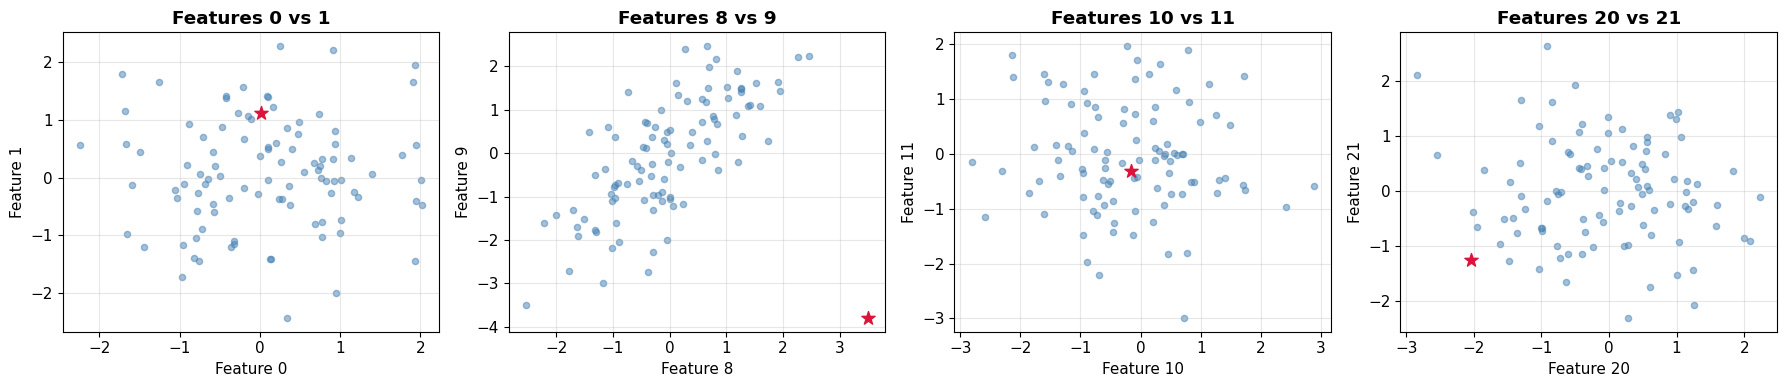

In [20]:
# Listing 6.11: SOD with synthetic high-dimensional data
from pyod.models.sod import SOD

np.random.seed(0)
d = np.random.randn(100, 35)
d = pd.DataFrame(d)
d[9] = d[9] + d[8]  # create correlation between features 8 and 9
d.loc[99, 8] = 3.5   # outlier in the correlated subspace
d.loc[99, 9] = -3.8

clf_sod = SOD(ref_set=3, contamination=0.01)
clf_sod.fit(d)
sod_scores = clf_sod.decision_scores_

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pairs = [(0, 1), (8, 9), (10, 11), (20, 21)]
for ax, (f1, f2) in zip(axes, pairs):
    flagged_sod = clf_sod.labels_ == 1
    ax.scatter(d.loc[~flagged_sod, f1], d.loc[~flagged_sod, f2], alpha=0.5, s=20, c='steelblue')
    ax.scatter(d.loc[flagged_sod, f1], d.loc[flagged_sod, f2], c='crimson', s=100, marker='*', zorder=5)
    ax.set_xlabel(f'Feature {f1}')
    ax.set_ylabel(f'Feature {f2}')
    ax.set_title(f'Features {f1} vs {f2}', fontweight='bold')

plt.tight_layout()

outlier_rank = np.argsort(sod_scores)[::-1].tolist().index(99) + 1
print(f"Figure 6.15: SOD on 35-feature data with outlier in features 8-9 subspace.")
print(f"  Row 99 (planted outlier) rank: {outlier_rank} of {len(d)}")
print(f"  Row 99 score: {sod_scores[99]:.4f}")
print(f"  The outlier is visible only in the features 8-9 subspace (2nd panel).")

This recreates Figure 6.15. The planted outlier (row $99$) is unusual *only* in features $8$ and $9$ -- it is completely normal in all other dimensions. SOD correctly identifies it because it searches for the relevant subspace.

The four panels show different feature pairs. Only the second panel (features $8$ vs $9$) reveals the outlier. A detector using all $35$ features with Euclidean distance would struggle because the outlier's signal is diluted across $33$ irrelevant features.

**FeatureBagging** takes a simpler but effective approach: create many random subspaces and let the ensemble capture whatever subspace-specific outliers exist. The key parameter is the number of features per subspace -- it should be kept small (much less than $d/2$) to avoid the curse of dimensionality within each base detector.

## 6.9 Comparing PyOD Detectors

Let's run several PyOD detectors on the same data and compare their results.

Detector Recall (planted outliers in top 20):
  KNN         : 95%
  PCA         : 95%
  CBLOF       : 95%
  ECOD        : 70%
  COPOD       : 65%
  HBOS        : 55%
  IForest     : 30%


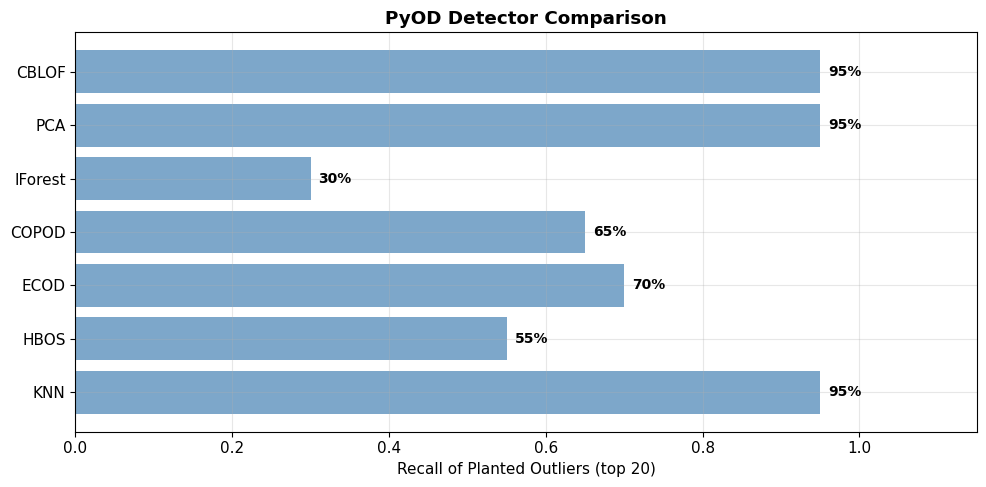

In [22]:
# Head-to-head comparison on synthetic data
from pyod.models.knn import KNN as PyOD_KNN
from pyod.models.hbos import HBOS
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.iforest import IForest
from pyod.models.pca import PCA as PyOD_PCA
from pyod.models.cblof import CBLOF

detectors = {
    'KNN': PyOD_KNN(),
    'HBOS': HBOS(),
    'ECOD': ECOD(),
    'COPOD': COPOD(),
    'IForest': IForest(random_state=42),
    'PCA': PyOD_PCA(),
    'CBLOF': CBLOF(n_clusters=10), # Changed from 3 to 10
}

results = {}
for name, det in detectors.items():
    det.fit(df_speech)
    scores = det.decision_scores_
    # Check recall of planted outliers
    top20 = set(np.argsort(scores)[-20:])
    planted = set(range(n_samples-20, n_samples))
    recall = len(top20 & planted) / len(planted)
    results[name] = {'recall': recall, 'scores': scores}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
recalls = [results[n]['recall'] for n in names]
bars = ax.barh(names, recalls, color='steelblue', alpha=0.7)
for bar, r in zip(bars, recalls):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{r:.0%}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Recall of Planted Outliers (top 20)')
ax.set_title('PyOD Detector Comparison', fontweight='bold')
ax.set_xlim(0, 1.15)

plt.tight_layout()

print("Detector Recall (planted outliers in top 20):")
for name in sorted(results.keys(), key=lambda n: -results[n]['recall']):
    print(f"  {name:12s}: {results[name]['recall']:.0%}")

The comparison reveals that different detectors have different strengths on this data. Some detectors (ECOD, COPOD, HBOS) excel at finding univariate extremes, while PCA and CBLOF may catch different patterns. IForest is typically a strong all-rounder.

The key takeaway: **no single detector dominates**. This is why PyOD's breadth is so valuable -- running multiple detectors and comparing or combining their results (via SUOD or manual ensembling) provides the most comprehensive detection.

## 6.10 SUOD and PyThresh

**SUOD** (Scalable Unsupervised Outlier Detection) accelerates training by running multiple detectors in parallel and combining their scores. It requires a separate install (`pip install suod`).

**PyThresh** provides $30+$ algorithms for thresholding continuous outlier scores into binary labels. Instead of using a fixed contamination rate, PyThresh statistically determines where the natural break between inliers and outliers lies. Recommended methods include FILTER, CLF, and META.

## 6.11 Chapter Summary

This chapter covered PyOD's rich ecosystem of outlier detectors:

**Univariate detectors (fast, scalable):**
- **HBOS**: Histogram-based, catches internal outliers, sensitive to n_bins
- **ECOD**: ECDF-based, parameter-free, tail-only detection, with explanations
- **COPOD**: Copula-based, parameter-free, similar to ECOD but more sophisticated

**Multivariate detectors:**
- **ABOD**: Angle-based, designed for high dimensions but mixed empirical results
- **CBLOF**: Clustering-based, evaluates points relative to large cluster centers
- **PCA / KPCA**: Reconstruction error captures pattern violations
- **SOD**: Subspace detection using shared nearest neighbors
- **FeatureBagging**: Ensemble of random-subspace detectors
- **Cook's Distance**: Regression influence-based

**Tools:**
- **SUOD**: Parallel training of multiple detectors
- **PyThresh**: Statistical thresholding of scores ($30+$ algorithms)
- **explain_outlier()**: Per-feature explanations (ECOD, COPOD only)

**Practical guidance:**
- Start with **ECOD** and **IForest** (PyOD's recommendation)
- Add **HBOS** for speed-critical or very-high-dimensional settings
- Add **CBLOF** when data has natural clusters
- Add **PCA** when features are correlated and pattern violations matter
- Use **SOD** or **FeatureBagging** when outliers hide in small subsets of many features
- **Combine** detectors via SUOD or manual ensembling for comprehensive coverage
- Use **PyThresh** to set thresholds without guessing contamination rates

In the next chapter, we explore additional outlier detection approaches not covered by scikit-learn or PyOD, including association rules and other categorical methods.

## Appendix: OpenML Dataset Examples (Run on Google Colab)

(3686, 400)


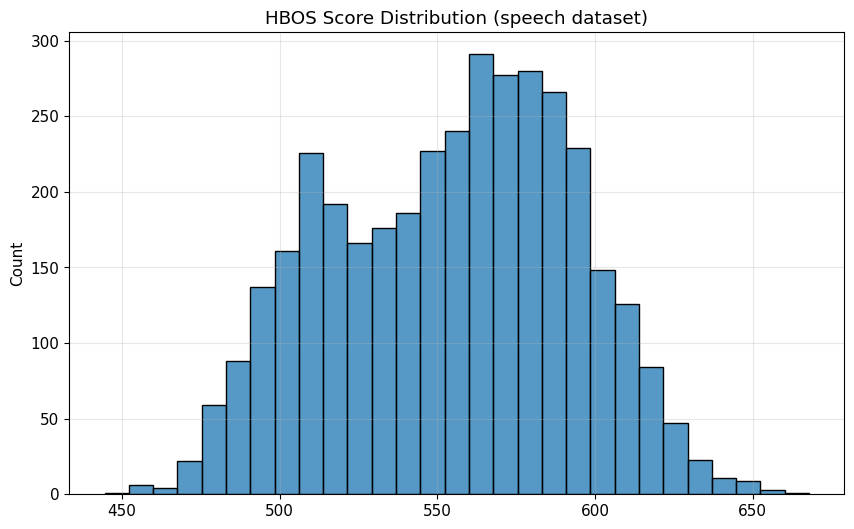

In [23]:
# Run on Google Colab -- Listing 6.4: HBOS on speech dataset
import pandas as pd
from pyod.models.hbos import HBOS
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.shape)

det = HBOS()
det.fit(df)
pred = det.decision_scores_
sns.histplot(pred)
plt.title('HBOS Score Distribution (speech dataset)')
plt.show()

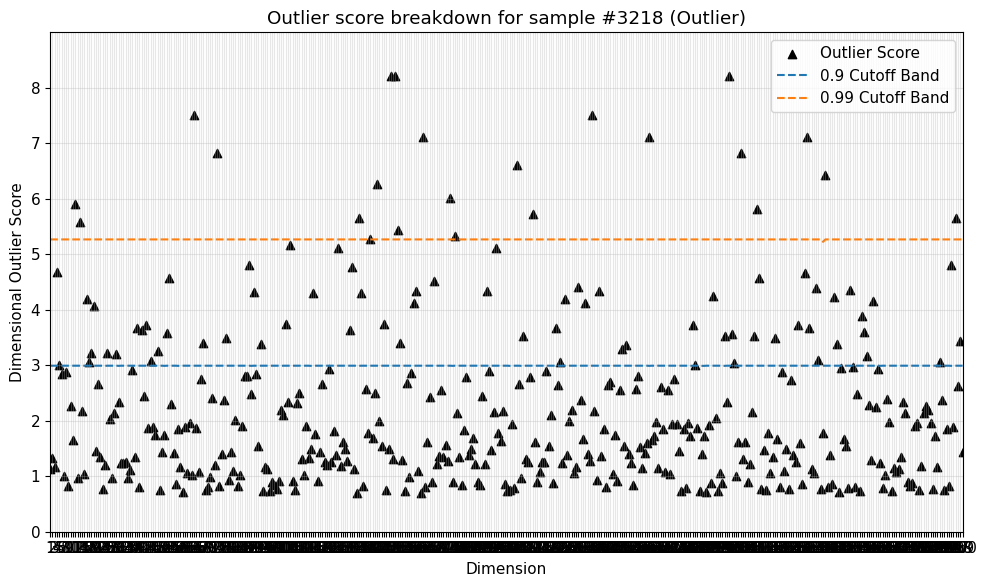

In [24]:
# Run on Google Colab -- Listing 6.7: ECOD with explain_outlier on speech
import pandas as pd
import numpy as np
from pyod.models.ecod import ECOD
from sklearn.datasets import fetch_openml

data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)

det = ECOD()
det.fit(df)
pred = det.decision_scores_
det.explain_outlier(np.argmax(pred))

In [26]:
# Run on Google Colab -- Listing 6.12: SUOD for parallel detector training
import pandas as pd
from pyod.models.iforest import IForest
from pyod.models.pca import PCA
from pyod.models.knn import KNN
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
# Install SUOD if not already installed
!pip install suod -q
from pyod.models.suod import SUOD
from sklearn.datasets import fetch_openml

data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)

detector_list = [IForest(), PCA(),
                 KNN(n_neighbors=10), KNN(n_neighbors=20),
                 KNN(n_neighbors=30), KNN(n_neighbors=40),
                 COPOD(), ABOD(), CBLOF()]

clf = SUOD(base_estimators=detector_list, n_jobs=2, combination='average', verbose=False)
clf.fit(df)
scores = clf.decision_scores_
print(f"SUOD scores range: [{scores.min():.4f}, {scores.max():.4f}]")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.1/172.1 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   13.4s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  5.0min finished


SUOD scores range: [-4.9281, 2.6056]
